# Comparing enrichment-score methods on scRNA-seq

`ov.es` ships GPU-accelerated drop-in replacements for `decoupler.mt`'s eleven scoring kernels. Every method exposes the same `(adata, signatures, engine)` API, so swapping the algorithm is a one-line change. This tutorial walks through every method on the same gene set, shows the math behind it, and visualises CPU vs GPU side by side.

The dataset and pathway are the same as in the [AUCell tutorial](../t_aucell.ipynb).

## Part.1 Data preprocess

In [1]:
import time
import numpy as np
import omicverse as ov
ov.style()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.3rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
adata = ov.datasets.pancreatic_endocrinogenesis()
adata

⚠️ File ./data/endocrinogenesis_day15.h5ad already exists
 Loading data from ./data/endocrinogenesis_day15.h5ad


✅ Successfully loaded: 3696 cells × 27998 genes


AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced'
    obsp: 'distances', 'connectivities'

In [3]:
# Subsample to keep mdt / udt CPU comparisons tractable; the UMAP
# pattern survives the downsampling.
rng = np.random.default_rng(0)
adata = adata[rng.choice(adata.n_obs, size=300, replace=False)].copy()
adata.var['robust'] = True
adata = ov.pp.preprocess(adata, target_sum=1e4)

🔍 [2026-05-17 23:27:17] Running preprocessing in 'cpu' mode...
Begin robust gene identification
    After filtration, 14182/27998 genes are kept.
    Among 14182 genes, 14182 genes are robust.
✅ Robust gene identification completed successfully.
Begin size normalization: shiftlog and HVGs selection pearson

🔍 Count Normalization:
   Target sum: 10000.0
   Exclude highly expressed: True
   Max fraction threshold: 0.2
   ⚠️ Excluding 1 highly-expressed genes from normalization computation
   Excluded genes: ['Ghrl']

✅ Count Normalization Completed Successfully!
   ✓ Processed: 300 cells × 14,182 genes
   ✓ Runtime: 0.02s

🔍 Highly Variable Genes Selection (Experimental):
   Method: pearson_residuals
   Target genes: 2,000
   Theta (overdispersion): 100



✅ Experimental HVG Selection Completed Successfully!
   ✓ Selected: 2,000 highly variable genes out of 14,182 total (14.1%)
   ✓ Results added to AnnData object:
     • 'highly_variable': Boolean vector (adata.var)
     • 'highly_variable_rank': Float vector (adata.var)
     • 'highly_variable_nbatches': Int vector (adata.var)
     • 'highly_variable_intersection': Boolean vector (adata.var)
     • 'means': Float vector (adata.var)
     • 'variances': Float vector (adata.var)
     • 'residual_variances': Float vector (adata.var)
    Time to analyze data in cpu: 0.43 seconds.
✅ Preprocessing completed successfully.
    Added:
        'highly_variable_features', boolean vector (adata.var)
        'means', float vector (adata.var)
        'variances', float vector (adata.var)
        'residual_variances', float vector (adata.var)
        'counts', raw counts layer (adata.layers)
    End of size normalization: shiftlog and HVGs selection pearson

╭─ SUMMARY: preprocess ───────────────────

In [4]:
pathway_dict = ov.utils.geneset_prepare(
    'genesets/GO_Biological_Process_2021.txt', organism='Mouse',
)
geneset_name = 'response to vitamin (GO:0033273)'
signatures = {geneset_name: pathway_dict[geneset_name]}

## Part.2 The unified API: `ov.es.decoupler`

Every method below is callable via `ov.es.<name>(...)` directly. But there's also a single dispatcher that takes the algorithm as a parameter:

```python
ov.es.decoupler(adata, signatures=sigs, method='aucell', engine='gpu')
# ↑ equivalent to ov.es.aucell(adata, signatures=sigs, engine='gpu')
```

Why have both? The dispatcher is handy when the choice of algorithm needs to be a runtime parameter — e.g. for benchmarking sweeps, configuration-driven pipelines, or agent tool-call interfaces. `ov.es.decoupler` is registered with omicverse's function registry so it can be discovered/invoked by agents.

In [5]:
# Same call, two ways:
ov.es.decoupler(adata, signatures=signatures, method='aucell', engine='gpu', tmin=3)
# ov.es.aucell  (adata, signatures=signatures,                 engine='gpu', tmin=3)
adata.obsm['score_aucell'].head()


╭─ SUMMARY: ov.es.aucell ────────────────────────────────────────────╮
│  Duration: 0.3796s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_aucell (dataframe, 300x1)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


,response to vitamin (GO:0033273)
GTGCAGCAGCTATGCT,0.00000
CAGATCAAGCTGTTCA,0.00000
GCAGCCAGTCATTAGC,0.00000
TACACGATCACCTTAT,0.16419
GCTTCCAAGACATAAC,0.00000


Each method below caches its CPU and GPU scores into small dictionaries plus `adata.obs` columns so the closing scatter and timing table can use them.

In [6]:
scores_cpu, scores_gpu, timings = {}, {}, {}

## ov.es.aucell

Per-cell ranking is followed by an area-under-the-recovery-curve integration:

$$ES_{i, F} = \int_0^1 R_{i, F}(r)\, dr$$

where $R_{i, F}(r)$ is the proportion of signature $F$ genes recovered in the top-$r$ fraction of cell $i$'s ranking. Reference: [Aibar et al., Nat Methods (2017)](https://doi.org/10.1038/nmeth.4463).

In [7]:
t = time.time()
ov.es.aucell(adata, signatures=signatures, tmin=3, engine='cpu')
timings[('aucell', 'cpu')] = time.time() - t
scores_cpu['aucell'] = adata.obsm['score_aucell'][geneset_name].astype(float).values
adata.obs['aucell (CPU)'] = scores_cpu['aucell']

t = time.time()
ov.es.aucell(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('aucell', 'gpu')] = time.time() - t
scores_gpu['aucell'] = adata.obsm['score_aucell'][geneset_name].astype(float).values
adata.obs['aucell (GPU)'] = scores_gpu['aucell']


╭─ SUMMARY: ov.es.aucell ────────────────────────────────────────────╮
│  Duration: 0.1846s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.aucell ────────────────────────────────────────────╮
│  Duration: 0.0261s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


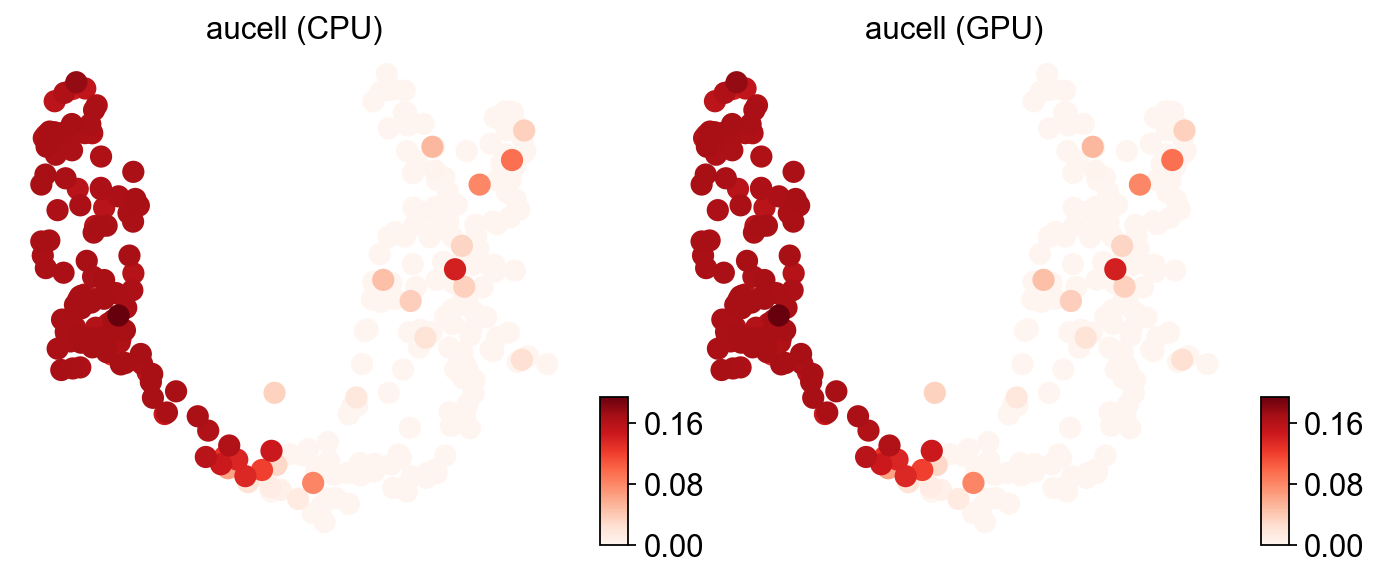

In [8]:
ov.pl.umap(adata, color=['aucell (CPU)', 'aucell (GPU)'], cmap='Reds', frameon=False)

## ov.es.gsea

Walk down a per-cell ranked list adding $|r_i|/\sum_{j\in F}|r_j|$ when a feature is in the set $F$, otherwise subtracting $1/(N-k)$. The enrichment score is the running sum's extremum:

$$\delta(F, i) = \begin{cases} \dfrac{|r_i|}{\sum_{j \in F} |r_j|} & i \in F \\[4pt] -\dfrac{1}{N - k} & i \notin F \end{cases}, \quad ES = L_{\arg\max |L|}$$

The GPU port handles the deterministic ES (`times=1`). For the CPU side we pass `times=50` — the numba kernel has a known bug at very small `times` values, but the deterministic ES it computes is the same regardless of the (unused) permutation block. Reference: [Subramanian et al., PNAS (2005)](https://doi.org/10.1073/pnas.0506580102).

In [9]:
t = time.time()
ov.es.gsea(adata, signatures=signatures, tmin=3, engine='cpu', times=50)
timings[('gsea', 'cpu')] = time.time() - t
scores_cpu['gsea'] = adata.obsm['score_gsea'][geneset_name].astype(float).values
adata.obs['gsea (CPU)'] = scores_cpu['gsea']

t = time.time()
ov.es.gsea(adata, signatures=signatures, tmin=3, engine='gpu', times=1)
timings[('gsea', 'gpu')] = time.time() - t
scores_gpu['gsea'] = adata.obsm['score_gsea'][geneset_name].astype(float).values
adata.obs['gsea (GPU)'] = scores_gpu['gsea']


╭─ SUMMARY: ov.es.gsea ──────────────────────────────────────────────╮
│  Duration: 0.8074s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_gsea (dataframe, 300x1)                         │
│           │ ✚ score_gsea (dataframe, 300x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ov.es.gsea ──────────────────────────────────────────────╮
│  Duration: 0.1042s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


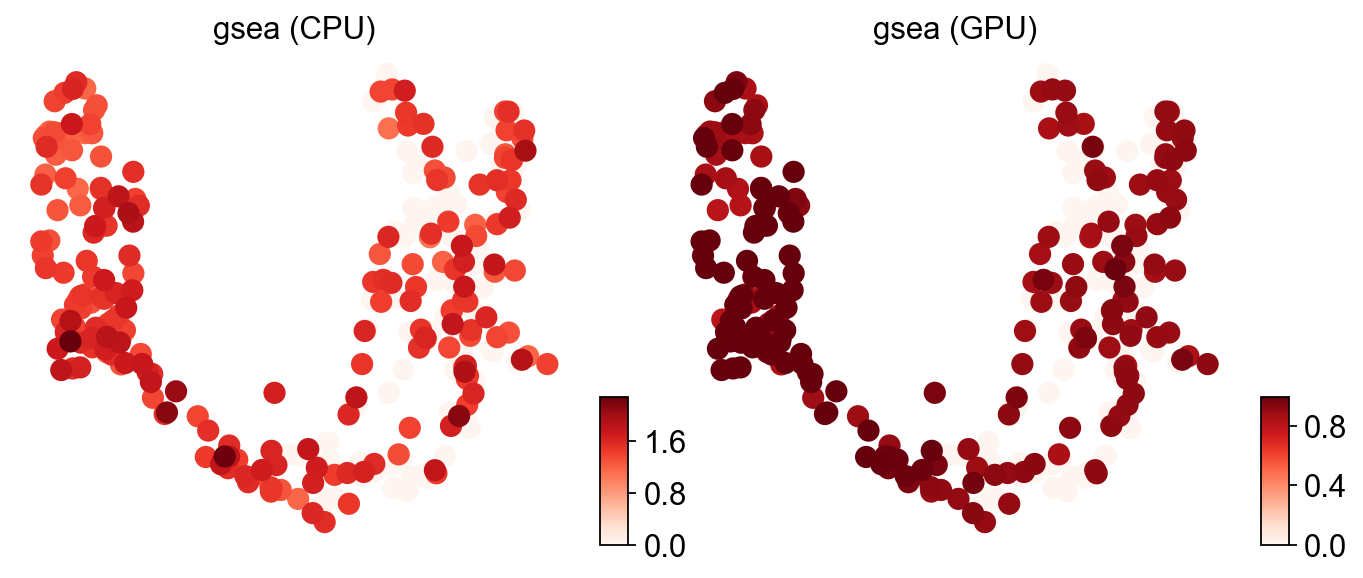

In [10]:
ov.pl.umap(adata, color=['gsea (CPU)', 'gsea (GPU)'], cmap='Reds', frameon=False)

## ov.es.gsva

Each feature is first transformed to a non-parametric CDF (Gaussian or Poisson kernel) and ranked per cell. Then a Kolmogorov–Smirnov-style walk yields:

$$ES = \max_{1 \le i \le N} L_i + \min_{1 \le i \le N} L_i$$

where $L$ is the running statistic. Reference: [Hänzelmann et al., BMC Bioinf (2013)](https://doi.org/10.1186/1471-2105-14-7).

In [11]:
t = time.time()
ov.es.gsva(adata, signatures=signatures, tmin=3, engine='cpu')
timings[('gsva', 'cpu')] = time.time() - t
scores_cpu['gsva'] = adata.obsm['score_gsva'][geneset_name].astype(float).values
adata.obs['gsva (CPU)'] = scores_cpu['gsva']

t = time.time()
ov.es.gsva(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('gsva', 'gpu')] = time.time() - t
scores_gpu['gsva'] = adata.obsm['score_gsva'][geneset_name].astype(float).values
adata.obs['gsva (GPU)'] = scores_gpu['gsva']


╭─ SUMMARY: ov.es.gsva ──────────────────────────────────────────────╮
│  Duration: 4.4971s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_gsva (dataframe, 300x1)                        │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ov.es.gsva ──────────────────────────────────────────────╮
│  Duration: 0.1369s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ─

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


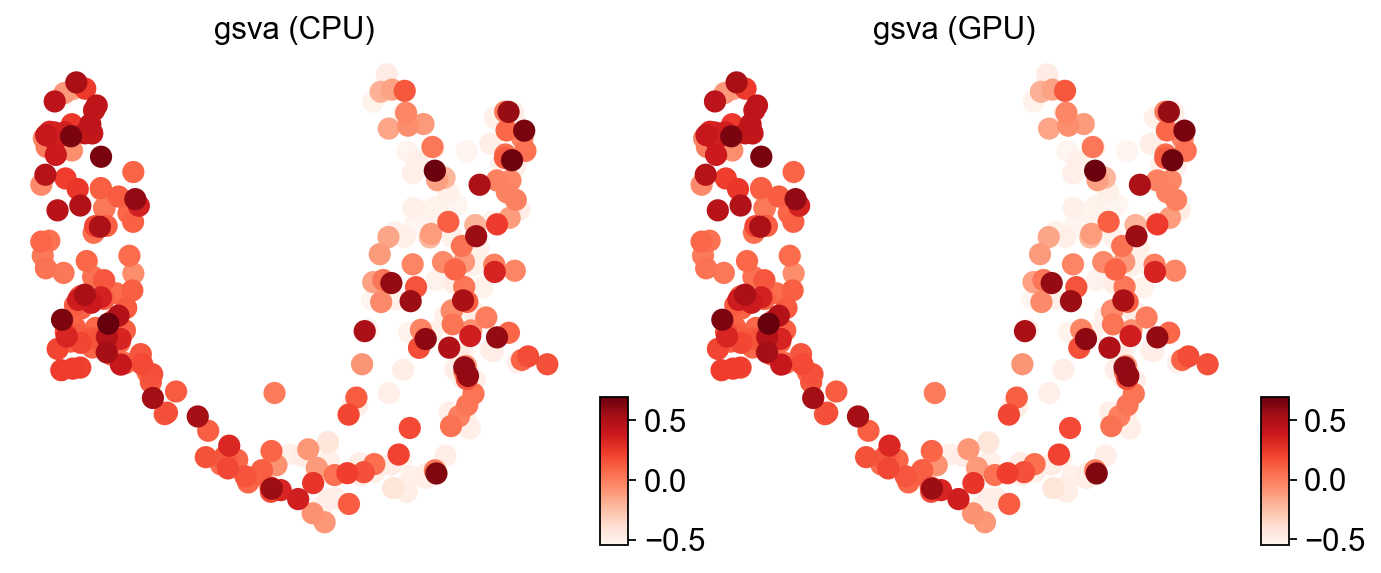

In [12]:
ov.pl.umap(adata, color=['gsva (CPU)', 'gsva (GPU)'], cmap='Reds', frameon=False)

## ov.es.ora

Build a 2×2 table of (significant / not) × (in-signature / not). The score is the log odds ratio with Haldane–Anscombe correction and the p-value comes from a Fisher exact test:

$$OR = \log\!\left(\frac{(a + 0.5)/(b + 0.5)}{(c + 0.5)/(d + 0.5)}\right), \quad p = P(X \ge a) \text{ under hypergeometric}$$

Reference: [Fisher, J R Stat Soc (1922)](https://doi.org/10.2307/2340521).

In [13]:
t = time.time()
ov.es.ora(adata, signatures=signatures, tmin=3, engine='cpu')
timings[('ora', 'cpu')] = time.time() - t
scores_cpu['ora'] = adata.obsm['score_ora'][geneset_name].astype(float).values
adata.obs['ora (CPU)'] = scores_cpu['ora']

t = time.time()
ov.es.ora(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('ora', 'gpu')] = time.time() - t
scores_gpu['ora'] = adata.obsm['score_ora'][geneset_name].astype(float).values
adata.obs['ora (GPU)'] = scores_gpu['ora']


╭─ SUMMARY: ov.es.ora ───────────────────────────────────────────────╮
│  Duration: 0.6625s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ora (dataframe, 300x1)                          │
│           │ ✚ score_ora (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ov.es.ora ───────────────────────────────────────────────╮
│  Duration: 0.0846s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


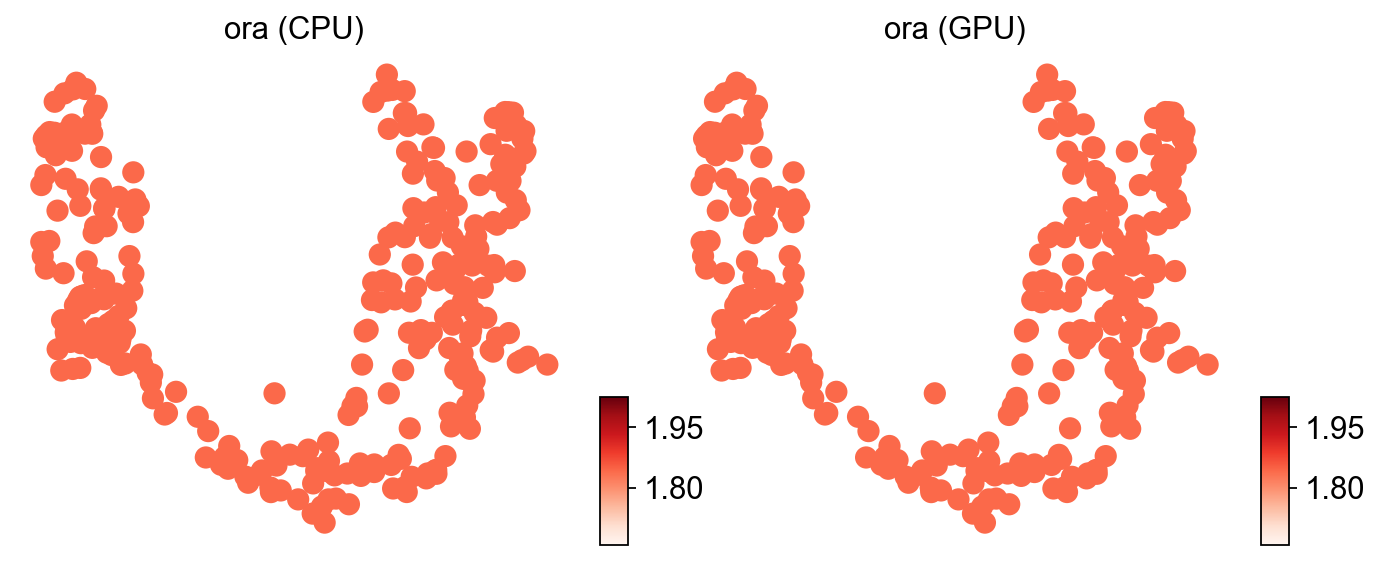

In [14]:
ov.pl.umap(adata, color=['ora (CPU)', 'ora (GPU)'], cmap='Reds', frameon=False)

## ov.es.ulm

One regression per (cell × signature): genes are observations, the cell's expression is the response, and the signature weights are the single regressor. The score is the slope's t-statistic:

$$y_i = \beta_0 + \beta_1 x_i + \varepsilon, \quad ES = t_{\beta_1} = \frac{\hat{\beta}_1}{\mathrm{SE}(\hat{\beta}_1)}, \quad p = 2\,\mathrm{sf}(|t|, \mathrm{df})$$

Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [15]:
t = time.time()
ov.es.ulm(adata, signatures=signatures, tmin=3, engine='cpu')
timings[('ulm', 'cpu')] = time.time() - t
scores_cpu['ulm'] = adata.obsm['score_ulm'][geneset_name].astype(float).values
adata.obs['ulm (CPU)'] = scores_cpu['ulm']

t = time.time()
ov.es.ulm(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('ulm', 'gpu')] = time.time() - t
scores_gpu['ulm'] = adata.obsm['score_ulm'][geneset_name].astype(float).values
adata.obs['ulm (GPU)'] = scores_gpu['ulm']


╭─ SUMMARY: ov.es.ulm ───────────────────────────────────────────────╮


│  Duration: 0.0979s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_ulm (dataframe, 300x1)                          │
│           │ ✚ score_ulm (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ov.es.ulm ───────────────────────────────────────────────╮
│  Duration: 0.0314s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ─

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


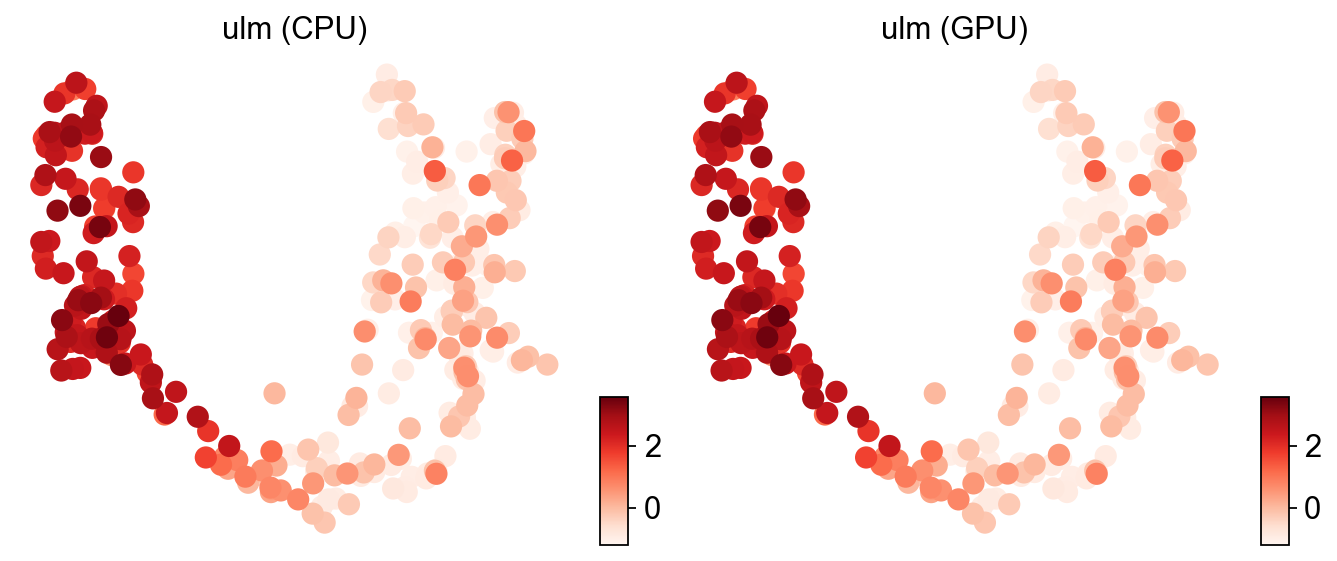

In [16]:
ov.pl.umap(adata, color=['ulm (CPU)', 'ulm (GPU)'], cmap='Reds', frameon=False)

## ov.es.mlm

The joint variant of ULM — one regression per cell with all signatures as covariates at once. The score for signature $j$ is the t-statistic of its coefficient:

$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_p x_p + \varepsilon, \quad ES_j = t_{\beta_j}$$

When signatures overlap, the joint fit deconfounds shared genes. Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [17]:
t = time.time()
ov.es.mlm(adata, signatures=signatures, tmin=3, engine='cpu')
timings[('mlm', 'cpu')] = time.time() - t
scores_cpu['mlm'] = adata.obsm['score_mlm'][geneset_name].astype(float).values
adata.obs['mlm (CPU)'] = scores_cpu['mlm']

t = time.time()
ov.es.mlm(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('mlm', 'gpu')] = time.time() - t
scores_gpu['mlm'] = adata.obsm['score_mlm'][geneset_name].astype(float).values
adata.obs['mlm (GPU)'] = scores_gpu['mlm']


╭─ SUMMARY: ov.es.mlm ───────────────────────────────────────────────╮
│  Duration: 0.164s                                                  │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_mlm (dataframe, 300x1)                          │
│           │ ✚ score_mlm (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ov.es.mlm ───────────────────────────────────────────────╮
│  Duration: 0.1005s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


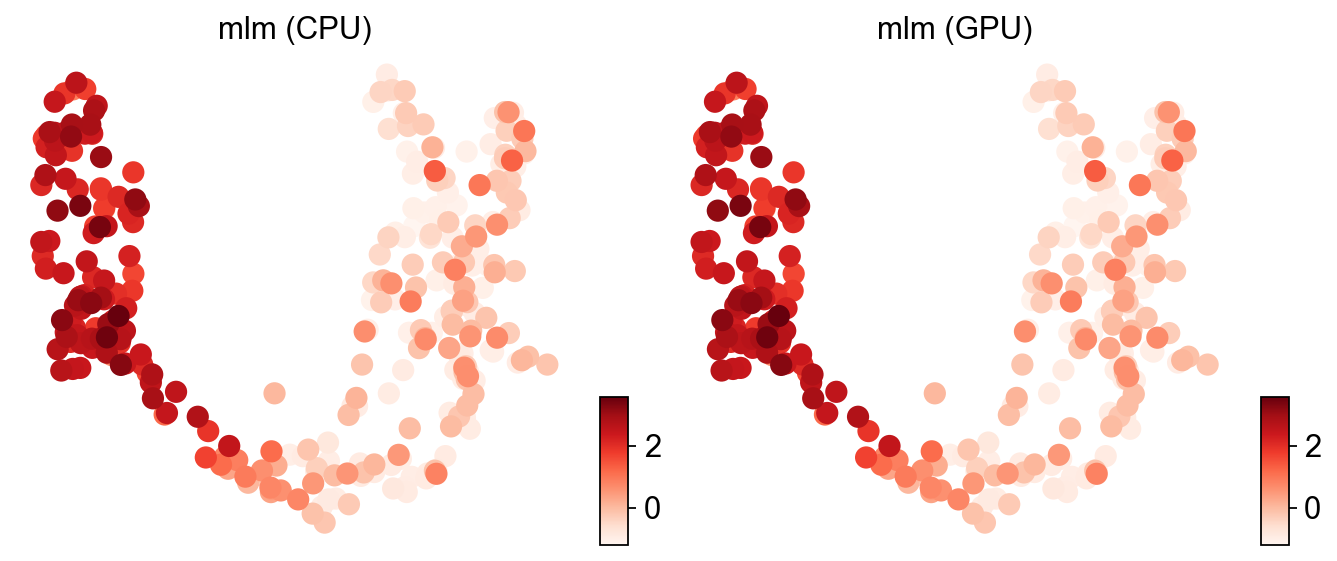

In [18]:
ov.pl.umap(adata, color=['mlm (CPU)', 'mlm (GPU)'], cmap='Reds', frameon=False)

## ov.es.waggr

The simplest scorer: a weighted aggregate of signature-gene expression. The default `fun='wmean'` is the weighted mean; `fun='wsum'` swaps in the unnormalised sum:

$$ES_{\mathrm{wmean}} = \frac{\sum_{i} w_i x_i}{\sum_i w_i}, \quad ES_{\mathrm{wsum}} = \sum_i w_i x_i$$

Fast and interpretable — the linear baseline that more elaborate scorers are benchmarked against. We pass `times=1` for the GPU to skip the permutation p-value pass and stay on-device. Reference: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016).

In [19]:
t = time.time()
ov.es.waggr(adata, signatures=signatures, tmin=3, engine='cpu', times=1)
timings[('waggr', 'cpu')] = time.time() - t
scores_cpu['waggr'] = adata.obsm['score_waggr'][geneset_name].astype(float).values
adata.obs['waggr (CPU)'] = scores_cpu['waggr']

t = time.time()
ov.es.waggr(adata, signatures=signatures, tmin=3, engine='gpu', times=1)
timings[('waggr', 'gpu')] = time.time() - t
scores_gpu['waggr'] = adata.obsm['score_waggr'][geneset_name].astype(float).values
adata.obs['waggr (GPU)'] = scores_gpu['waggr']


╭─ SUMMARY: ov.es.waggr ─────────────────────────────────────────────╮
│  Duration: 1.1056s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_waggr (dataframe, 300x1)                        │
│           │ ✚ score_waggr (dataframe, 300x1)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ov.es.waggr ─────────────────────────────────────────────╮
│  Duration: 0.0292s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


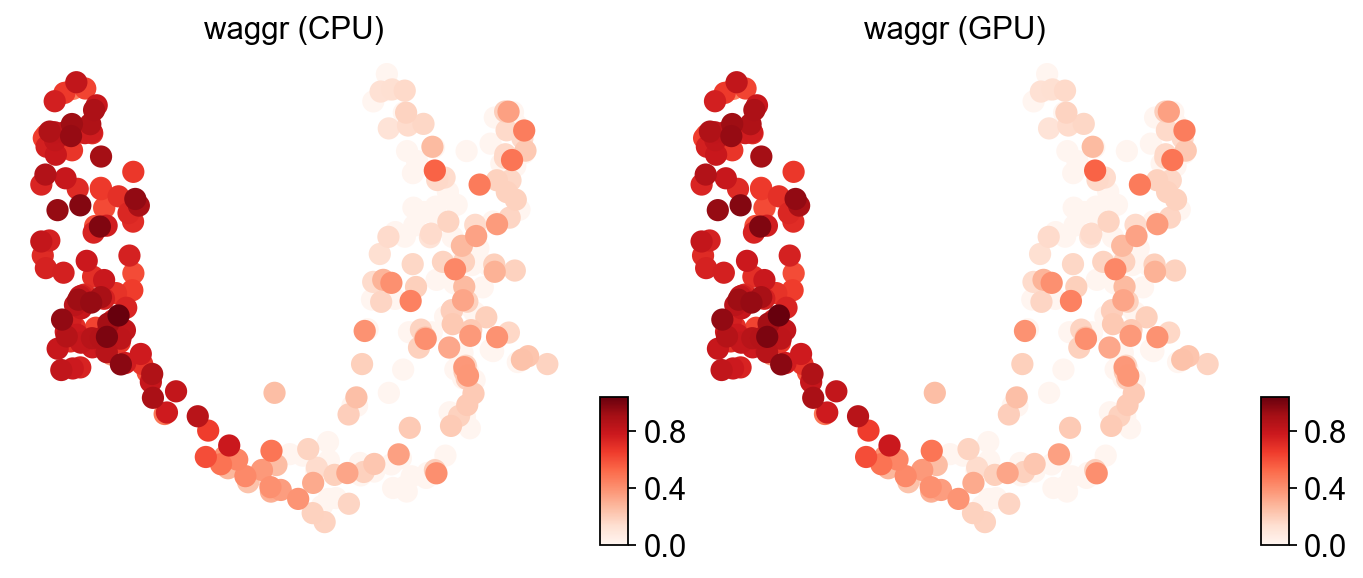

In [20]:
ov.pl.umap(adata, color=['waggr (CPU)', 'waggr (GPU)'], cmap='Reds', frameon=False)

## ov.es.zscore

Standardise the signature mean against an empirical null built from all features in the same cell:

$$ES = \frac{(\mu_F - \mu_{\mathrm{all}})\sqrt{m}}{\sigma_{\mathrm{all}}}$$

where $m = |F|$. Reference: [Yılmaz et al., Nat Commun (2021)](https://doi.org/10.1038/s41467-021-21211-6).

In [21]:
t = time.time()
ov.es.zscore(adata, signatures=signatures, tmin=3, engine='cpu')
timings[('zscore', 'cpu')] = time.time() - t
scores_cpu['zscore'] = adata.obsm['score_zscore'][geneset_name].astype(float).values
adata.obs['zscore (CPU)'] = scores_cpu['zscore']

t = time.time()
ov.es.zscore(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('zscore', 'gpu')] = time.time() - t
scores_gpu['zscore'] = adata.obsm['score_zscore'][geneset_name].astype(float).values
adata.obs['zscore (GPU)'] = scores_gpu['zscore']


╭─ SUMMARY: ov.es.zscore ────────────────────────────────────────────╮
│  Duration: 0.0809s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_zscore (dataframe, 300x1)                       │
│           │ ✚ score_zscore (dataframe, 300x1)                      │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯



╭─ SUMMARY: ov.es.zscore ────────────────────────────────────────────╮
│  Duration: 0.0305s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


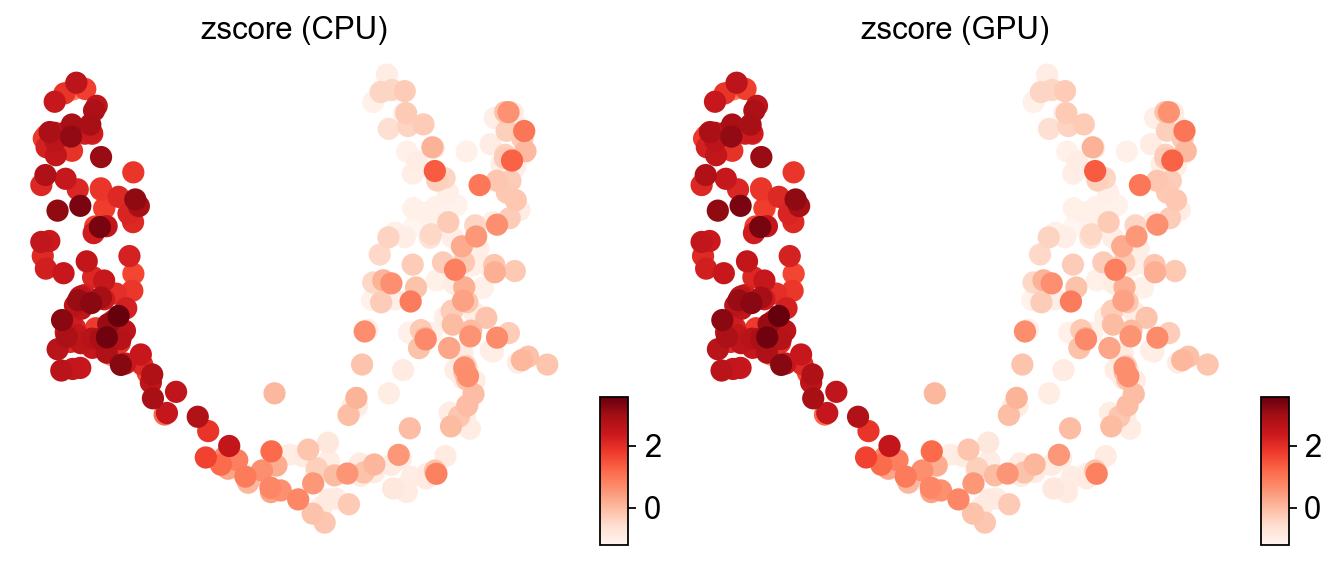

In [22]:
ov.pl.umap(adata, color=['zscore (CPU)', 'zscore (GPU)'], cmap='Reds', frameon=False)

## ov.es.viper

Treats the signature as a regulon and computes an analytical rank-based enrichment (aREA) score with a magnitude term $S_1$, a directional term $S_2$, and an optional pleiotropy correction:

$$S_3 = \begin{cases} (|S_2| + S_1)\,\mathrm{sgn}(S_2) & S_1 > 0 \\ S_2 & S_1 \le 0 \end{cases}, \quad ES = S_3 \sqrt{\sum_i l_{i}^{2}}, \quad p = 2\,\bar{\Phi}(|ES|)$$

Reference: [Alvarez et al., Nat Genet (2016)](https://doi.org/10.1038/ng.3593).

In [23]:
t = time.time()
ov.es.viper(adata, signatures=signatures, tmin=3, engine='cpu')
timings[('viper', 'cpu')] = time.time() - t
scores_cpu['viper'] = adata.obsm['score_viper'][geneset_name].astype(float).values
adata.obs['viper (CPU)'] = scores_cpu['viper']

t = time.time()
ov.es.viper(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('viper', 'gpu')] = time.time() - t
scores_gpu['viper'] = adata.obsm['score_viper'][geneset_name].astype(float).values
adata.obs['viper (GPU)'] = scores_gpu['viper']


╭─ SUMMARY: ov.es.viper ─────────────────────────────────────────────╮
│  Duration: 0.2799s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ padj_viper (dataframe, 300x1)                        │
│           │ ✚ score_viper (dataframe, 300x1)                       │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯

╭─ SUMMARY: ov.es.viper ─────────────────────────────────────────────╮
│  Duration: 0.0478s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  C

X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


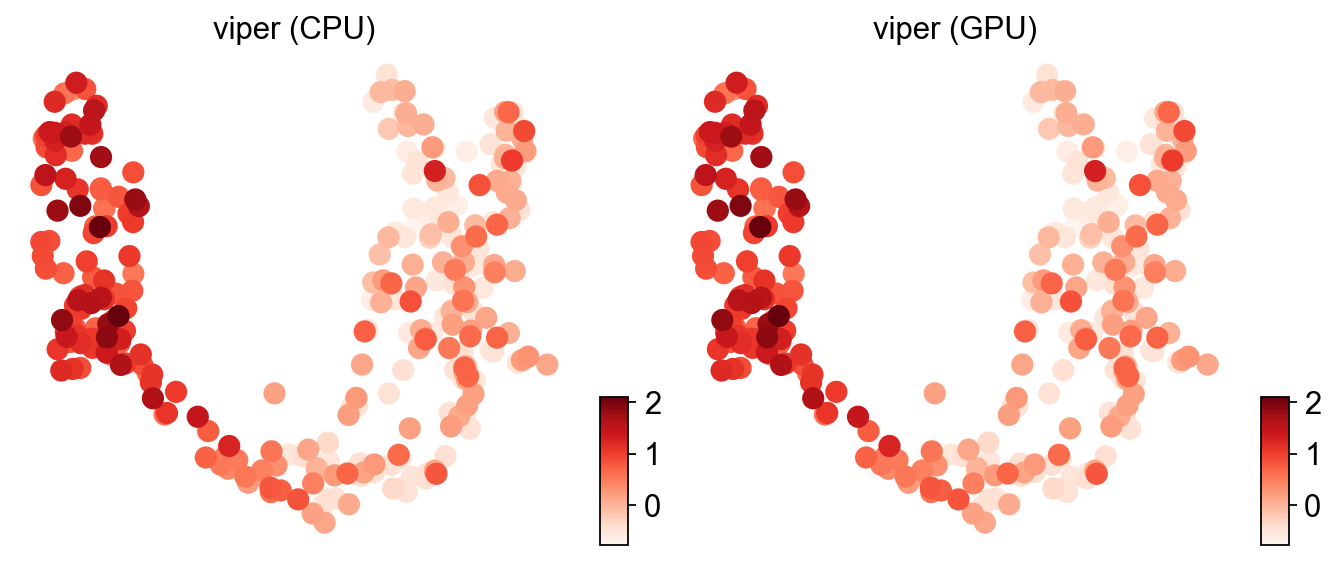

In [24]:
ov.pl.umap(adata, color=['viper (CPU)', 'viper (GPU)'], cmap='Reds', frameon=False)

## ov.es.mdt

Fit one gradient-boosted decision tree (XGBoost) per cell with all signatures as covariates. The score for signature $j$ is the normalised feature importance — the share of split gains across the ensemble attributable to that signature.

$$ES_j = \frac{\sum_{\text{splits on } j} \text{gain}}{\sum_{j'} \sum_{\text{splits on } j'} \text{gain}}$$

MDT's CPU baseline fits one `xgboost.XGBRegressor` per cell, which is impractically slow at scRNA scale (minutes per thousand cells) — exactly the bottleneck the torch GBDT in `_engine.py` exists to remove. We run GPU only here; the CPU column in the closing summary is therefore blank for MDT. References: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016); [Chen & Guestrin, KDD (2016)](https://doi.org/10.1145/2939672.2939785).

In [25]:
t = time.time()
ov.es.mdt(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('mdt', 'gpu')] = time.time() - t
scores_gpu['mdt'] = adata.obsm['score_mdt'][geneset_name].astype(float).values
adata.obs['mdt (GPU)'] = scores_gpu['mdt']


╭─ SUMMARY: ov.es.mdt ───────────────────────────────────────────────╮
│  Duration: 1.5974s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_mdt (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


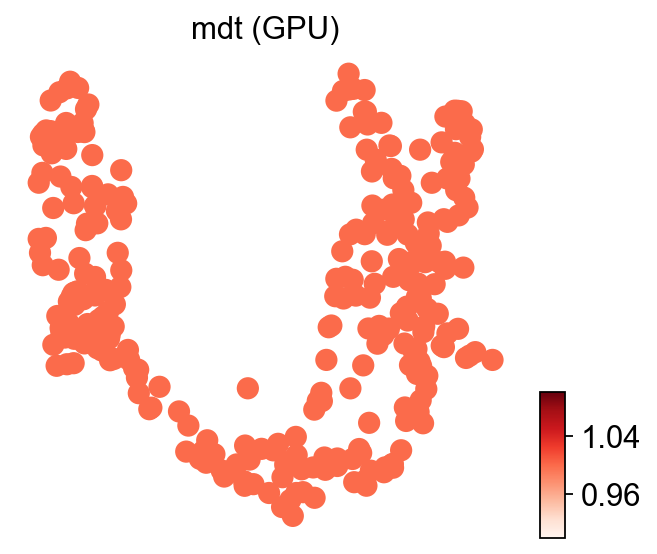

In [26]:
ov.pl.umap(adata, color='mdt (GPU)', cmap='Reds', frameon=False)

## ov.es.udt

Per (cell × signature), fit a univariate gradient-boosted decision tree using the single signature's weights as the regressor. The score is the model's coefficient of determination:

$$ES = R^2 = 1 - \frac{\sum_g (y_g - \hat{y}_g)^2}{\sum_g (y_g - \bar{y})^2}$$

Like MDT, UDT fits one `xgboost` per (cell × signature) — even more expensive at scale than MDT — so we run GPU only here too. References: [Badia-i-Mompel et al., Bioinformatics Advances (2022)](https://doi.org/10.1093/bioadv/vbac016); [Chen & Guestrin, KDD (2016)](https://doi.org/10.1145/2939672.2939785).

In [27]:
t = time.time()
ov.es.udt(adata, signatures=signatures, tmin=3, engine='gpu')
timings[('udt', 'gpu')] = time.time() - t
scores_gpu['udt'] = adata.obsm['score_udt'][geneset_name].astype(float).values
adata.obs['udt (GPU)'] = scores_gpu['udt']


╭─ SUMMARY: ov.es.udt ───────────────────────────────────────────────╮
│  Duration: 0.1748s                                                 │
│  Shape:    300 x 14,182 (Unchanged)                                │
│                                                                    │
│  CHANGES DETECTED                                                  │
│  ────────────────                                                  │
│  ● OBSM   │ ✚ score_udt (dataframe, 300x1)                         │
│                                                                    │
╰────────────────────────────────────────────────────────────────────╯


X_umap converted to UMAP to visualize and saved to adata.obsm['UMAP']
if you want to use X_umap, please set convert=False


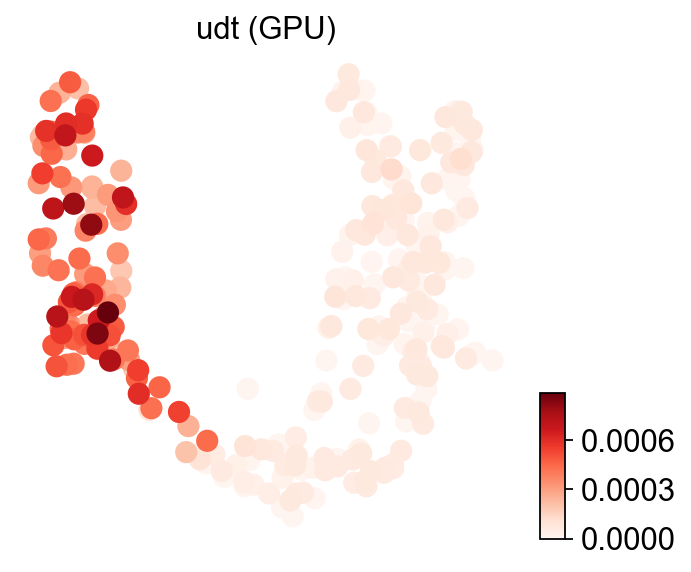

In [28]:
ov.pl.umap(adata, color='udt (GPU)', cmap='Reds', frameon=False)

## Part.3 CPU vs GPU scatter — all methods with a CPU baseline

Each point is one cell; x = CPU score, y = GPU score. Points on the diagonal mean perfect agreement. Different colours = different methods.

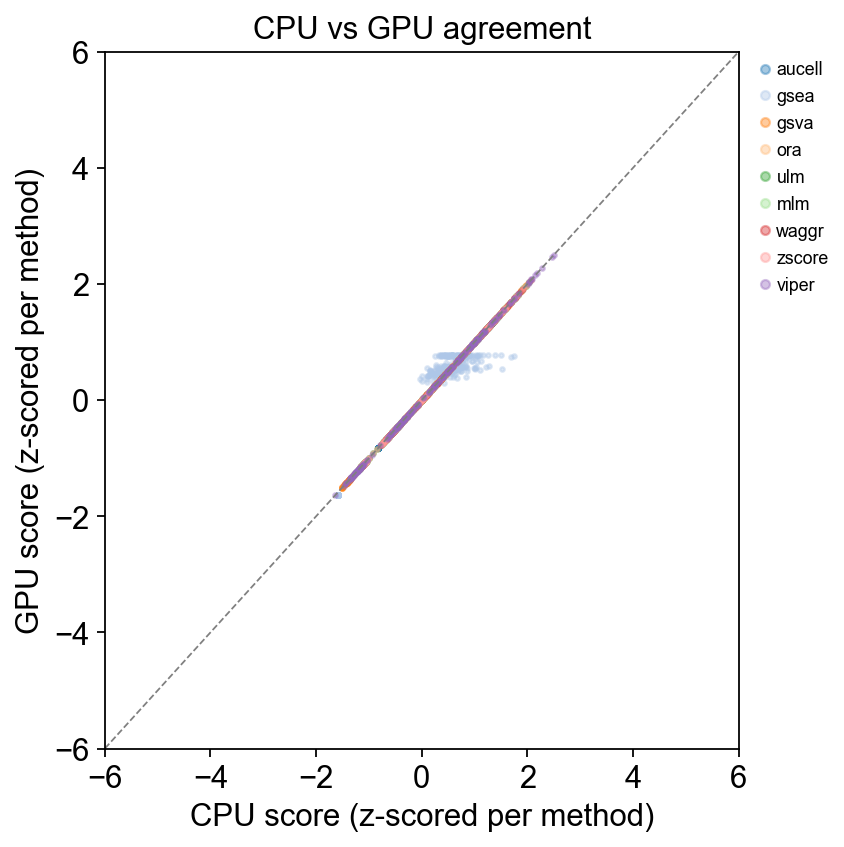

In [29]:
import matplotlib.pyplot as plt

_methods = [m for m in scores_gpu if m in scores_cpu]
_cmap = plt.get_cmap('tab20')
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for _i, _m in enumerate(_methods):
    _x = scores_cpu[_m]
    _y = scores_gpu[_m]
    _xz = (_x - _x.mean()) / (_x.std() + 1e-12)
    _yz = (_y - _y.mean()) / (_y.std() + 1e-12)
    ax.scatter(_xz, _yz, s=4, alpha=0.4, label=_m, color=_cmap(_i % _cmap.N))
ax.plot([-6, 6], [-6, 6], '--', color='grey', lw=0.8)
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_xlabel('CPU score (z-scored per method)')
ax.set_ylabel('GPU score (z-scored per method)')
ax.set_title('CPU vs GPU agreement')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, markerscale=2)
plt.tight_layout()
plt.show()

## Part.4 Speedup and accuracy table

In [30]:
import pandas as pd
from scipy.stats import pearsonr, spearmanr

rows = []
for _m in [m for m in scores_gpu if m in scores_cpu]:
    _x = scores_cpu[_m]
    _y = scores_gpu[_m]
    _rmse = float(np.sqrt(np.mean((_x - _y) ** 2)))
    _rng = float(_x.max() - _x.min())
    rows.append({
        'method': _m,
        'CPU (s)': round(timings[(_m, 'cpu')], 2),
        'GPU (s)': round(timings[(_m, 'gpu')], 2),
        'speedup': round(timings[(_m, 'cpu')] / max(timings[(_m, 'gpu')], 1e-6), 1),
        'pearson r': round(pearsonr(_x, _y)[0], 4),
        'spearman r': round(spearmanr(_x, _y)[0], 4),
        'rmse / range': round(_rmse / _rng if _rng > 0 else 0.0, 4),
    })
pd.DataFrame(rows).set_index('method')

,CPU (s),GPU (s),speedup,pearson r,spearman r,rmse / range
method,,,,,,
aucell,0.19,0.03,6.8,1.0000,1.0000,0.0000
gsea,0.81,0.11,7.7,0.9747,0.8019,0.2224
gsva,4.50,0.14,32.5,1.0000,1.0000,0.0001
ora,0.66,0.09,7.7,NaN,NaN,0.0000
ulm,0.10,0.03,3.0,1.0000,1.0000,0.0000
mlm,0.17,0.10,1.6,1.0000,1.0000,0.0000
waggr,1.11,0.03,36.1,1.0000,1.0000,0.0000
zscore,0.08,0.03,2.6,1.0000,1.0000,0.0000
viper,0.28,0.05,5.7,1.0000,1.0000,0.0000
